In [ ]:
import pandas as pd
import numpy as np

# Load the dataset.
df = pd.read_csv("Telco-Customer-Churn.csv")

In [31]:
# Quick sanity check of the first few records.
df_raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [32]:
# Review schema and missing values before preprocessing.
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Convert TotalCharges to numeric; invalid values become NaN.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values in TotalCharges with the median.
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop customerID because it is an identifier, not a predictive feature.
df.drop('customerID', axis=1, inplace=True)

In [34]:
# Encode target label as binary values: Yes -> 1, No -> 0.
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# One-hot encode categorical features; drop_first avoids dummy trap.
df_model = pd.get_dummies(df, drop_first=True)

In [35]:
# Confirm transformed feature set.
df_model.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [36]:
# Validate that no null values remain after preprocessing.
df_model.isnull().sum().sort_values(ascending=False).head(10)

SeniorCitizen                            0
OnlineBackup_Yes                         0
PaymentMethod_Electronic check           0
PaymentMethod_Credit card (automatic)    0
PaperlessBilling_Yes                     0
Contract_Two year                        0
Contract_One year                        0
StreamingMovies_Yes                      0
StreamingMovies_No internet service      0
StreamingTV_Yes                          0
dtype: int64

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Select encoded features and target label.
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Scale features so all columns are on a comparable range.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train logistic regression with class balancing for imbalanced labels.
model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


Accuracy: 0.7473385379701917

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.51      0.82      0.63       373

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



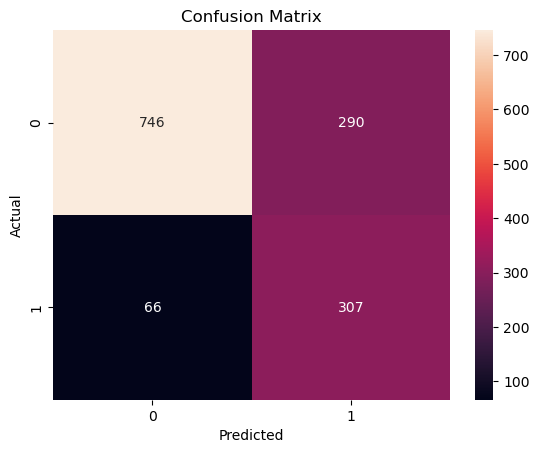

AUC Score: 0.8619108863746935


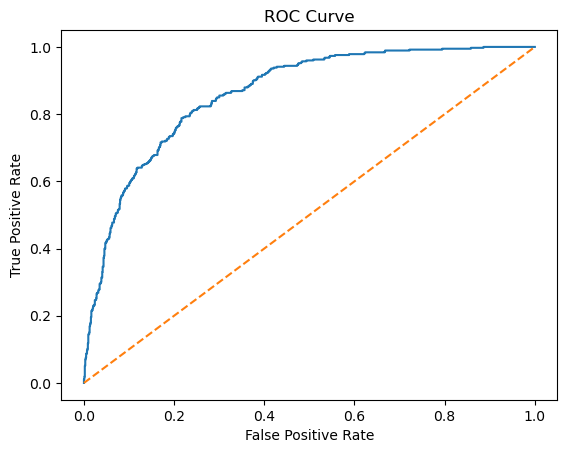


Top Features Influencing Churn:

                           Feature  Coefficient
10     InternetService_Fiber optic     0.678793
3                     TotalCharges     0.602746
23             StreamingMovies_Yes     0.266040
21                 StreamingTV_Yes     0.212693
9                MultipleLines_Yes     0.163081
28  PaymentMethod_Electronic check     0.161700
26            PaperlessBilling_Yes     0.153173
0                    SeniorCitizen     0.057086
17            DeviceProtection_Yes     0.030839
5                      Partner_Yes     0.018095

Final Model Performance:
Accuracy: 0.7473385379701917
AUC Score: 0.8619108863746935


In [41]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Generate class predictions and positive-class probabilities.
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Compute and print core classification metrics.
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Build and display confusion matrix.
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot ROC curve and calculate AUC.
roc_auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", roc_auc)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# Show top features based on model coefficients.
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nTop Features Influencing Churn:\n")
print(coefficients.head(10))

# Print final summary metrics.
print("\nFinal Model Performance:")
print("Accuracy:", accuracy)
print("AUC Score:", roc_auc)